# Hierarchical Clustering

## Introduction

Hierarchical Clustering is an **unsupervised learning** algorithm that groups data into a hierarchy of clusters. Unlike K-Means, it does **not require the number of clusters (K)** to be specified beforehand.

---

## Limitations of K-Means Clustering

K-Means relies on **distance from centroids**, making it suitable primarily for **spherical or circular clusters**.

It performs poorly when clusters have:
- Arbitrary or complex shapes
- Non-convex boundaries
- Unequal sizes or densities

![](./images/img2.png)

---

## Types of Hierarchical Clustering

1. Agglomerative Clustering (Bottom-Up)
2. Divisive Clustering (Top-Down)

---

## Agglomerative Clustering

Agglomerative Clustering is the **most commonly used** hierarchical clustering method.

### Algorithm

1. Treat each data point as an individual cluster.
2. Compute the distance between all clusters.
3. Merge the two closest clusters into a new cluster.
4. Repeat Steps 2 and 3 until all data points belong to a single cluster.
5. Record each merge operation.

The sequence of merge operations forms a tree-like structure called a **dendrogram**.

![](./images/img3.png)

### Obtaining Final Clusters

- To obtain the desired number of clusters, **cut (truncate) the dendrogram** at an appropriate height.
- Each connected component below the cut represents a cluster.

---

## Divisive Clustering

Divisive Clustering is the **reverse** of Agglomerative Clustering.

### Algorithm

1. Start with all data points in a single cluster.
2. Recursively split clusters into smaller clusters.
3. Continue splitting until each data point forms its own cluster or another stopping criterion is met.

### Note

- Divisive Clustering is less commonly used because **splitting clusters is generally more computationally difficult than merging them**.
- Therefore, **Agglomerative Clustering is preferred in practice**.

---

## Comparison

| Agglomerative Clustering | Divisive Clustering |
|--------------------------|---------------------|
| Bottom-up approach | Top-down approach |
| Starts with each data point as a separate cluster | Starts with a single cluster containing all data points |
| Merges the closest clusters | Splits clusters recursively |
| More commonly used | Less commonly used |
| Simpler and computationally more practical | Computationally more expensive |

# Agglomerative Clustering Algorithm

## Algorithm

1. Initialize the **proximity (distance) matrix**.
2. Treat each data point as an individual cluster.
3. Repeat the following steps until only one cluster remains:
   1. Merge the two closest clusters.
   2. Update the proximity matrix to reflect the new cluster distances.
4. Record each merge to construct the **dendrogram**.

---

## Types of Agglomerative Clustering (Based on Linkage)

### Single Link (Minimum Linkage)

- The distance between two clusters is the **minimum distance** between any pair of points from the two clusters.
- Can capture clusters with arbitrary shapes but is sensitive to noise and may produce a chaining effect.

### Complete Link (Maximum Linkage)

- The distance between two clusters is the **maximum distance** between any pair of points from the two clusters.
- Produces compact, well-separated clusters but is sensitive to outliers.

### Average Link

- The distance between two clusters is the **average distance** between all pairs of points in the two clusters.
- Provides a balance between single linkage and complete linkage.

### Ward Linkage (Default in scikit-learn)

- Merges the pair of clusters that results in the **minimum increase in within-cluster variance (WCSS)**.
- Generally produces compact, spherical clusters and often gives the best overall performance.

---

## Determining the Number of Clusters

- Plot the **dendrogram**.
- Draw a horizontal line that intersects the **longest vertical distance** (largest gap without merges).
- The number of clusters equals the number of branches intersected by the horizontal line.

---

## Important Hyperparameters

### `n_clusters`

- Specifies the number of clusters to be formed.
- Ignored if `distance_threshold` is specified.

### `affinity`

- Specifies the distance metric used to compute similarity (e.g., Euclidean, Manhattan, Cosine).
- Used only when the linkage method supports it (not applicable for Ward linkage).

### `linkage`

- Determines how the distance between clusters is computed during merging.
- Common options are **single**, **complete**, **average**, and **ward**.

### `distance_threshold`

- Specifies the maximum linkage distance for merging clusters.
- If set, clustering stops when this threshold is reached instead of using `n_clusters`.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import numpy as np

In [3]:
customer_data = pd.read_csv("dataset/hierarchical-clustering-with-python-and-scikit-learn-shopping-data.csv")

In [4]:
customer_data.shape

(200, 5)

In [5]:
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data = customer_data.iloc[:, 3:5].values

In [ ]:
data

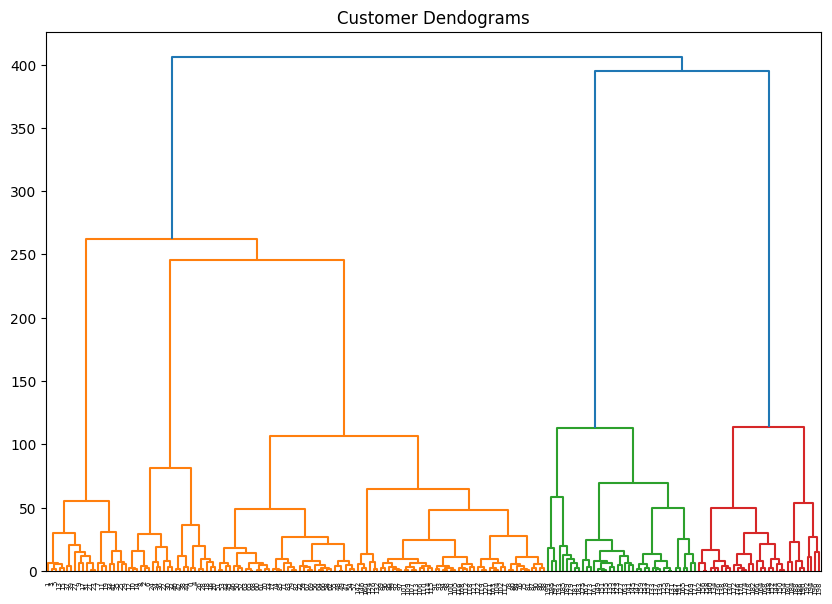

In [8]:
import scipy.cluster.hierarchy as shc 

plt.figure(figsize=(10,7))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(data,method="ward"))

In [12]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_=cluster.fit_predict(data)

In [14]:
labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

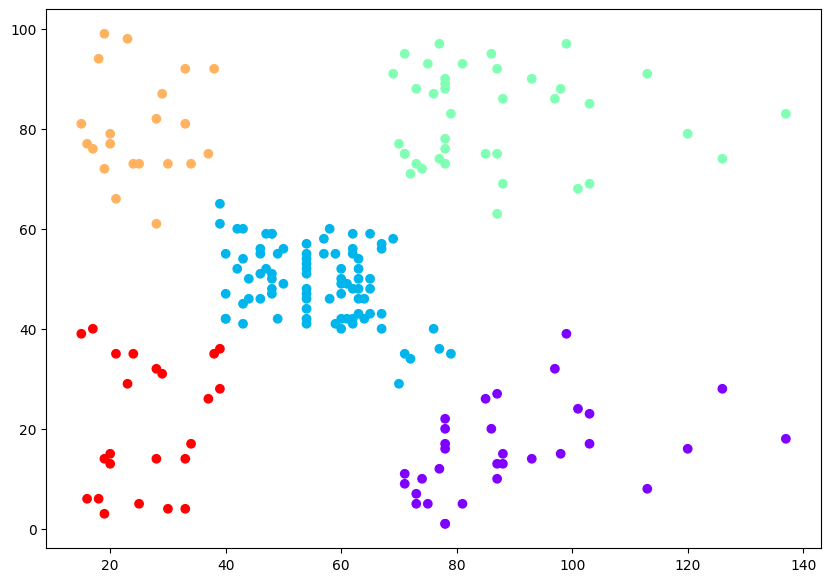

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(data[:,0], data[:,1], c=cluster.labels_, cmap='rainbow')